In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 2000

In [3]:
def h(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = r2 - r1
    return pref * (r1[0] + r2[0]) * d[1] - lam * np.sqrt(np.sum(d**2))

In [4]:
def g12(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = pt2 - pt1 + 1.5
    d %= 1
    d -= 0.5
    lambd = lam * d / np.sqrt(np.sum(d**2))
    g1x = pref * d[1] + lambd[0]
    g1y = -pref * (r1[0] + r2[0]) + lambd[1]
    g2x = pref * d[1] - lambd[0]
    g2y = pref * (r1[0] + r2[0]) - lambd[1]
    return np.array([g1x, g1y]), np.array([g2x, g2y])

<Figure size 640x480 with 0 Axes>

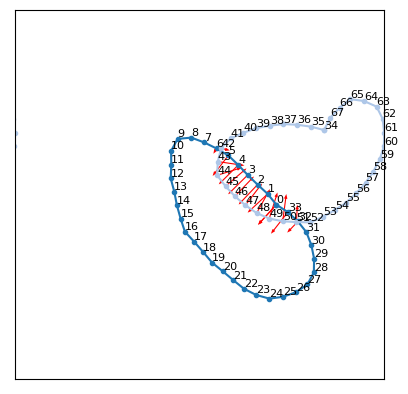

In [5]:
lam = 0.0
pref = 1
numPolygons = 2
n = 34
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 0
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 4.0, phi = 0.2)
#m.setPositions((m.getPositions() + 0.5) % 1)
plt.clf()
# Works fine
m.setMaxEdgeLength(0.5)
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h, g12 = g12, lam = lam, pref = pref)
# Now you have dA, can you draw arrows on the vertices?
ax = m.draw(numbering = True, forces = force, arrowColor = 'r')

In [6]:
startPos = m.getPositions()
m.minimizeGD(h = h, g12 = g12, lam = lam, pref = pref, maxSteps = maxSteps)
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h = h, g12 = g12, lam = lam, pref = pref)
force0 = m.getConstrainedForce(force)
positions0 = m.getPositions()
#positions0 = np.load("pos0.npy")
#force0 = np.load("force0.npy")
#m.setPositions(positions0)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900


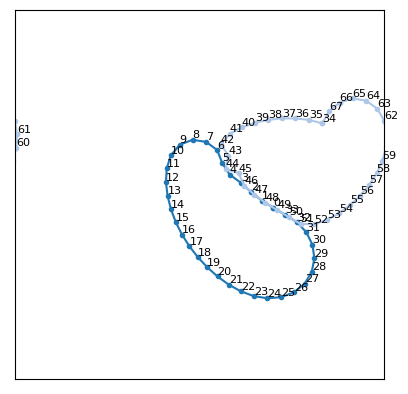

In [7]:
ax = m.draw(numbering = True, forces = force0, arrowColor = 'r')

In [8]:
np.max(np.abs(force0))

0.001325625707971155

In [9]:
# I think this is working properly. Perhaps even better than I thought
# it would. Let's add in a changing lambda value and see if anything different happens

In [10]:
lam = 0.05
pref = 1
numPolygons = 2
n = 34
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 0
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 4.0, phi = 0.2)
#m.setPositions((m.getPositions() + 0.5) % 1)
plt.clf()
# Works fine
m.setMaxEdgeLength(0.5)
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h, g12 = g12, lam = lam, pref = pref)
# Now you have dA, can you draw arrows on the vertices?

<Figure size 640x480 with 0 Axes>

In [11]:
m.minimizeGD(h = h, g12 = g12, lam = lam, pref = pref, maxSteps = maxSteps)
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h = h, g12 = g12, lam = lam, pref = pref)
force005 = m.getConstrainedForce(force)
positions005 = m.getPositions()
#positions005 = np.load("pos005.npy")
#force005 = np.load("force005.npy")
#m.setPositions(positions005)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900


In [12]:
np.max(np.abs(force005))

0.0

AttributeError: 'list' object has no attribute 'plot'

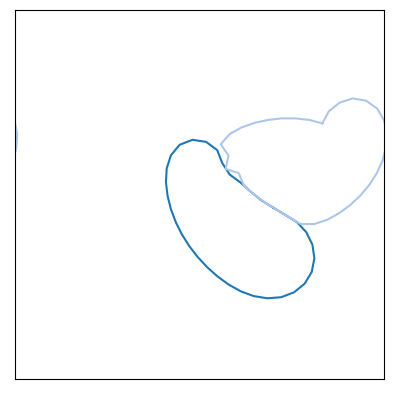

In [13]:
m.setPositions(positions0)
ax = m.draw(ms = 0)
m.setPositions(positions005)
m.draw(ax = ax, ms = 3)

In [ ]:
lam = 0.01
pref = 0
numPolygons = 2
n = 34
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 0
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 4.0, phi = 0.2)
#m.setPositions((m.getPositions() + 0.5) % 1)
plt.clf()
# Works fine
m.setMaxEdgeLength(0.5)
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h, g12 = g12, lam = lam, pref = pref)
# Now you have dA, can you draw arrows on the vertices?

In [ ]:
m.minimizeGD(h = h, g12 = g12, lam = lam, pref = pref, maxSteps = maxSteps)
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h = h, g12 = g12, lam = lam, pref = pref)
forceINF = m.getConstrainedForce(force)
positionsINF = m.getPositions()
#positionsINF = np.load("posINF.npy")
#forceINF = np.load("forceINF.npy")
#m.setPositions(positionsINF)

In [ ]:
np.max(np.abs(forceINF))

In [ ]:
m.setPositions(positions0)
ax = m.draw(ms = 1)
m.setPositions(positions005)
m.draw(ax = ax, ms = 1)
m.setPositions(positionsINF)
m.draw(ax = ax, ms = 3)

In [ ]:
# This confirms my suspicion. When lambda is large, it becomes happy to
# be stuck together. It doesn't go inside and try to consume the whole
# shebang, but it does leave an overlap. What if we let that overlap 
# have some small amount of overlap area penalty:

In [ ]:
lam = 0.2
pref = 0.01
numPolygons = 2
n = 34
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 0
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 4.0, phi = 0.2)
#m.setPositions((m.getPositions() + 0.5) % 1)
plt.clf()
# Works fine
m.setMaxEdgeLength(0.5)
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h, g12 = g12, lam = lam, pref = pref)
# Now you have dA, can you draw arrows on the vertices?

In [ ]:
m.minimizeGD(h = h, g12 = g12, lam = lam, pref = pref, maxSteps = maxSteps)
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h = h, g12 = g12, lam = lam, pref = pref)
forceLARGE = m.getConstrainedForce(force)
positionsLARGE = m.getPositions()
#positionsLARGE = np.load("posLarge.npy")
#forceLARGE = np.load("forceLarge.npy")
#m.setPositions(positionsLARGE)

In [ ]:
np.max(np.abs(forceLARGE))

In [ ]:
m.setPositions(positions0)
ax = m.draw(ms = 0)
m.setPositions(positions005)
m.draw(ax = ax, ms = 1)
m.setPositions(positionsINF)
m.draw(ax = ax, ms = 3)
m.setPositions(positionsLARGE)
m.draw(ms = 6)
np.save("startPos", startPos)
np.save("pos0", positions0)
np.save("pos005", positions005)
np.save("posINF", positionsINF)
np.save("posLarge", positionsLARGE)
np.save("startPos", startPos)
np.save("force0", force0)
np.save("force005", force005)
np.save("forceINF", forceINF)
np.save("forceLarge", forceLARGE)
print(np.load("posLarge.npy"))